In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1
cupy_device = device.index if device.type == "cuda" else 0
def single_S(y,x_left,x_right,y_below,y_upper,center,r): # Single source
    return np.exp(-300*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): # Total source
    S_1= single_S(y,x_left,x_right,y_below,y_upper,center[0],r)
    S_2= single_S(y,x_left,x_right,y_below,y_upper,center[1],r)
    S_3= single_S(y,x_left,x_right,y_below,y_upper,center[2],r)
    S_4= single_S(y,x_left,x_right,y_below,y_upper,center[3],r)
    return S_1+S_2+S_3+S_4



cuda:1


## 1

In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
# b_x_min,b_x_max,b_y_min,b_y_max=-0.55,0.55,-0.55,0.55 # On boundary Gamma

num_batches_gauss=1
b_n=97
points_b=mea_2d.p_b_circle(alpha=1,radius=0.5,n=b_n,temp=True) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[0.15,0.15],[-0.15,0.15],[-0.15,-0.15],[0.15,-0.15]]) # Centers of the four sources
number_gene=200
eps=0.01
batch_number_rec_mea,mea=2,1


S_int_true1, F_mea_b1, F_mea_db1= generate_data.boundary_data_rec(kk, number_gene, points_b, ana_S,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F_1=inverse_solver.F(F_mea_b1,F_mea_db1)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


In [3]:
M=3200
af="sin"   # Initial activation setting
R_m=20
models0 = net_2d.pre_define(Nx,Ny,M,R_m,"sin",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


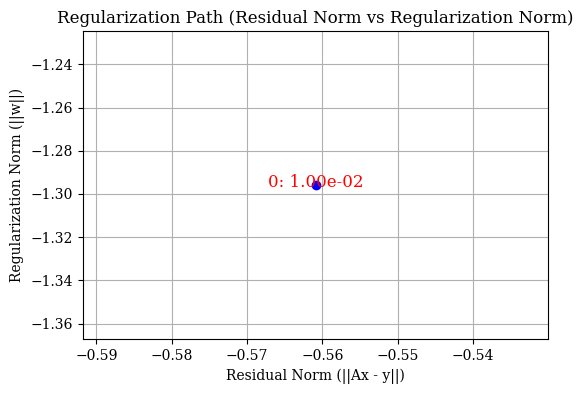

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


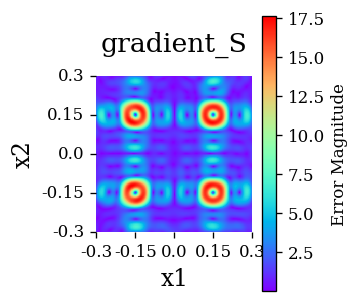

S_l_inf= 1.3601874154540616 S_L_2= 0.11620360184795445 S_l_2= 0.48337725948765514


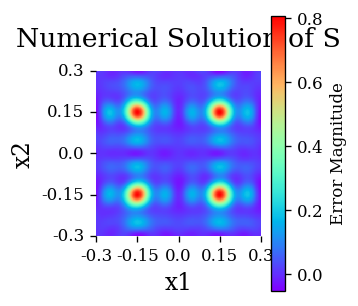

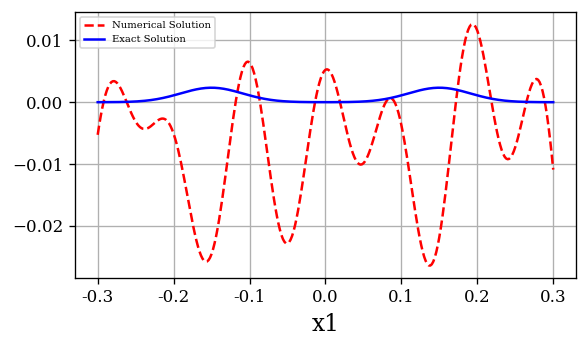

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


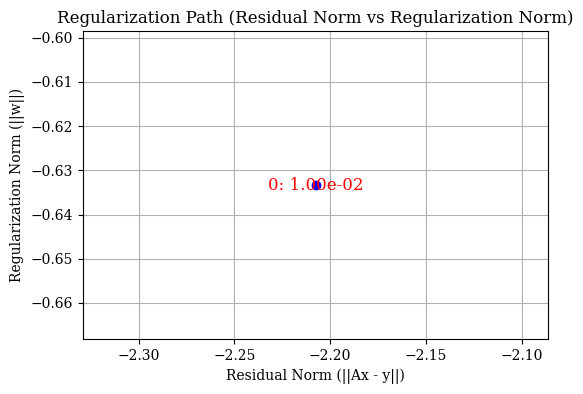

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


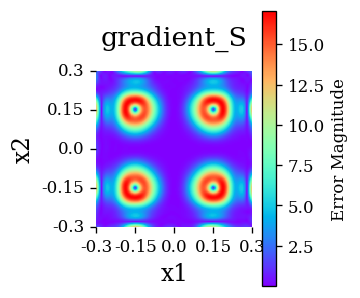

S_l_inf= 0.3857605928539766 S_L_2= 0.012898276051468425 S_l_2= 0.05365352907074121


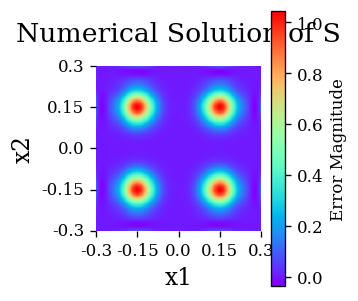

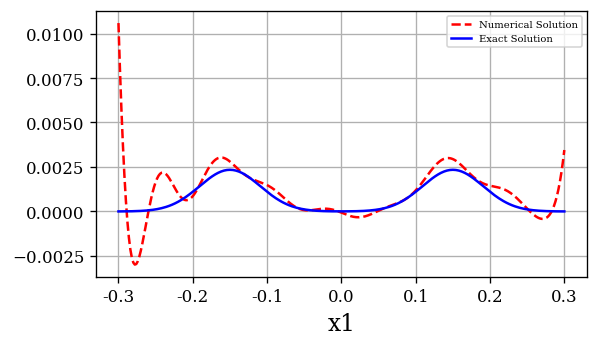

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


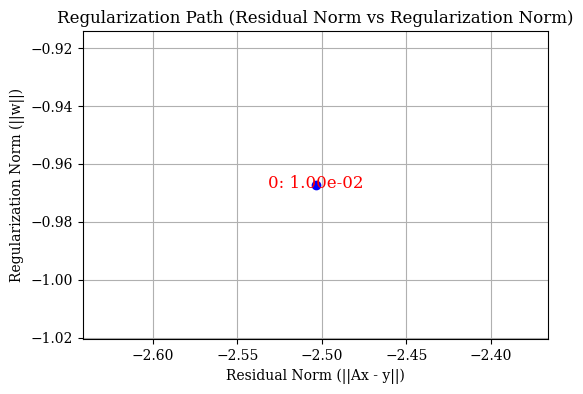

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


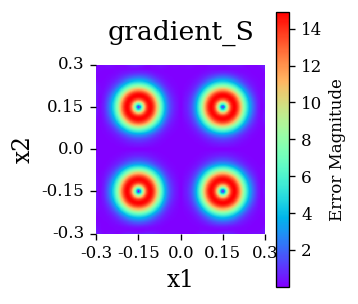

S_l_inf= 0.02947990825118062 S_L_2= 0.0006595439790810971 S_l_2= 0.0027435342454956452


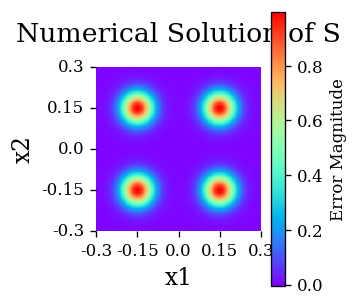

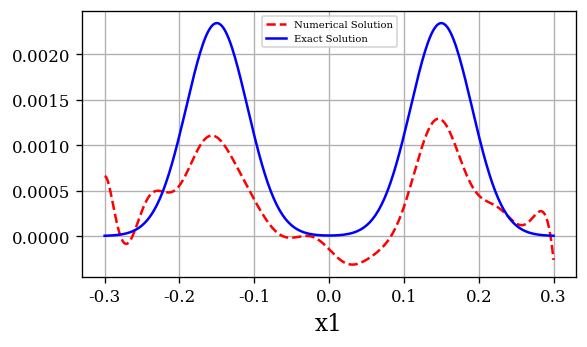

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


In [13]:
iter_int= 3
Ix,Iy=5,5  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-2,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="sin"
refine_threshold_S=[1e-4, 5e-4, 1e-4, 5e-4, 1e-3] # Use smaller thresholds initially for more refinement, then larger thresholds for less refinement.
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
# using main.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_1,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)


In [14]:
point_number[-1]

2250

In [15]:
# Save the models1 model
torch.save(models0,f"./results/pi/models0_33_3200_{point_number[-1]}_10-4.pth")


In [16]:
np.save("./results/pi/S_num_store",S_num_store)


In [17]:
import pickle # Import the pickle module
output_pickle_file = "./results/pi/cells_store_last.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store[-1], f)